In [84]:
import numpy as np

from matplotlib import pyplot as plt
from scipy.stats import beta, uniform, norm
from scipy.optimize import minimize_scalar

# Rejection Sampling

Before getting into importance sampling, we briefly discuss rejection sampling. The goal of this section is to describe 

- What rejection sampling is,
- What is the algorithm,
- Provide a simulation

**What is rejection sampling?**

When concerned with the goal of generating a random sample $X_1, \ldots, X_n$ from a given distribution $f(x|\theta)$, rejection sampling is one type of method of achieving this goal.

This method is an *indirect method* of transforming uniform random variables into the desired distribution. It is indirect in the sense that it is used when no easily available direct transformation of a uniform random variable $U$ to the desired distribtion $Y = g(U)$ exists. We motivate rejection sampling via the following example:

Assume our goal is to generate a sample $Y \sim \text{Beta}(a, b)$. Set $a = 2.7$ and $b = 6.3$ for definiteness, and denote $f_Y(y)$ to be the beta probability density. Below is the plot of said density, with the red-shaded region $P(Y \leq y)$.


(0.0, 1.5)

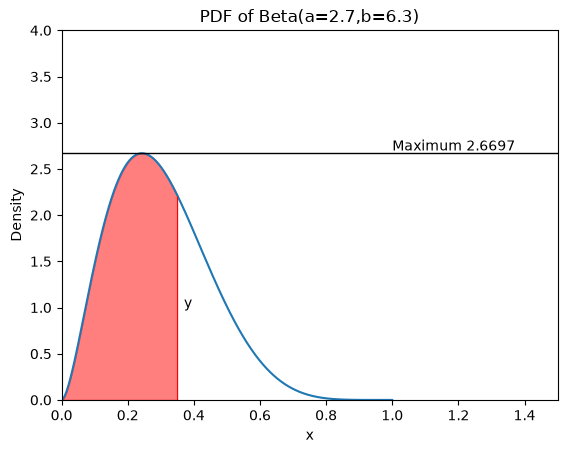

In [120]:
a = 2.7
b = 6.3

x_grid = np.linspace(0, 1, 1000)
beta_pdf = beta.pdf(x_grid, a, b)


fy_val = beta_pdf[350]
fy_max = np.max(beta_pdf) 
plt.plot(
    x_grid,
    beta_pdf
)
plt.vlines(x=0.35, ymin=0, ymax=fy_val, color="red", lw=0.7)
plt.fill_between(
    x_grid,
    beta_pdf,
    where = (x_grid >=0) & (x_grid <= 0.35),
    color = "red",
    alpha = 0.5,
)
plt.axhline(fy_max, lw=1, color="black")
plt.text(0.37, 1.0, "y")
plt.text(1.0, 2.7, f"Maximum {fy_max:.4f}")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("PDF of Beta(a=2.7,b=6.3)")
plt.ylim((0,4))
plt.xlim((0,1.5))


Let $U$ and $V$ be iid from a $\text{Uniform}(0,1)$ distribution. Let $c \geq \max_y f_Y(y)$. We may express the beta probabilities from the uniform probabilities
by noting that
$$
P(V \leq y,\; U \leq \frac{1}{c}f_Y(V)) = \int_{0}^y \int_0^{f_Y(v)/c} du dv = \frac{1}{c}\int_{0}^{y}f_Y(v)dv = \frac{1}{c}P(Y \leq y)
$$

This suggests to us that we can generate beta samples from the uniform samples. 

If we specifically set $y=1$, then $P(Y \leq 1) = 1$ and $P(V \leq 1) = 1$ so that our relation above becomes
$$
\frac{1}{c} = P(U \leq \frac{1}{c}f_Y(V))\;.
$$
Plugging this into the original relation yields
$$
P(Y \leq y) = c \cdot P(V \leq y,\; U \leq \frac{1}{c}f_Y(V))
 = \frac{P(V \leq y,\; U \leq \frac{1}{c}f_Y(V))}{P(U \leq \frac{1}{c}f_Y(V))}
$$
which yields the conditional distribution
$$
P(Y \leq y) = P(V \leq y \mid U \leq \frac{1}{c} f_Y(V))\;.
$$

In other words, the probability that $Y \leq y$ is equal to the probability that $V \leq y$ given that $U \leq \frac{1}{c} f_Y(V)$. This allows us to construct the following algorithm which can be seen as the basis for the rejection sampling algorithm: 

To generate $Y \sim \text{Beta}(a,b)$,
1. Draw $U$ and $V$ independently from a $\text{Uniform}(0,1)$.
2. If $U \leq \frac{1}{c}f_Y(V)$, set $Y = V$; otherwise, return to step 1.

We note that the above holds for $c \geq \max_y f_Y(y)$ and the optimal choice for $c = \max_y f_Y(y)$. The reason for this is due to the fact that expected number of $(U,V)$ pairs required to get one $Y$ is $c$. So to optimize our chance of success, we choose the minimum possible $c$. 

To reach the official algorithm, we end by noting that, for the right tail of the beta distribution, the chances we land in the tail region is much lower than the uniform counter part. There is a large area where $U > \frac{1}{c} f_Y(V)$, and so the algorithm will contain many rejections before an acceptance. Instead, if we propose a different distribution for $V$ such that it is closer to the beta, we reduce said area where $U > \frac{1}{c} f_Y(V)$.

We therefore can generalize step 2. as follows: if $V \sim f_V$, let $M = \sup_y \frac{f_Y(y)}{f_V(y)} < \infty$. Then step 2. becomes:

- Compare $U \sim \text{Uniform}(0,1)$ to $\frac{1}{M}\frac{f_Y(y)}{f_V(y)}$.

The larger this ratio is, the more $V$ looks like a random variable from $f_Y$.

**Final Algorithm**
1. Generate $U \sim \text{Uniform}(0,1)$, and $V \sim f_V$, independently.
2. If $U < \frac{1}{M} f_Y(y) / f_V(v)$, set $Y = V$; otherwise, return to step 1.

**Note**

In order for this algorithm to work, we need the following to hold:
1. We need to be able to generate samples from the proposal density $f_V(v)$,
2. The importance ratio $(f_Y(v) / f_V(v))$ must have a known bound; i.e. there exists $M < \infty$ such that $(f_Y(v) / f_V(v)) < M$.

Additionally, we need not have a density in the denominator of the importance ratio. We only need that the function (in the denominator) be
proportional to a density, have finite integral, and we can draw from said density. Let us call this function, the unormalized function, $g(x)$. Then the most common approach to making draws from $g(x)$ is to choose $g(x)$ such that it matches the algebraic kernel of a known distribution. For example, we may choose $g(x) = \exp(-x^2/2)$ which is the kernel for a standard normal density. As such we can make draws from $N(0,1)$ and then use $g(x)$ to compute the importance ratio.

We code up the specific case below:

In [121]:
c = np.max(fy_max)
n_trials = 0

# generate sample function:
def gen_beta_simple(a, b, n_samples=1):
    n_fails = 0
    beta_samples = np.zeros((n_samples,))

    for i in range(n_samples):
        y = np.inf
        while (y == np.inf):
            # Step 1
            U = uniform.rvs()
            V = uniform.rvs()
            fV = beta.pdf(V, a=a, b=b)
            # Step 2
            if (U < (1/c) * fV):
                y = V
                beta_samples[i] = y
            else:
                n_fails += 1
                continue

    return beta_samples, n_fails

# Generating one sample and reporting number of failed samples
y, n_fails = gen_beta_simple(a=a, b=b, n_samples=1)

print(f"Sample y = {y}, with {n_fails} rejections")

Sample y = [0.11579927], with 2 rejections


The following takes the above, generates a large sample (1000 samples), and plots the histogram. We see that the rejection sampling results matches well the true beta density it is trying to generate samples from.

<function matplotlib.pyplot.show(close=None, block=None)>

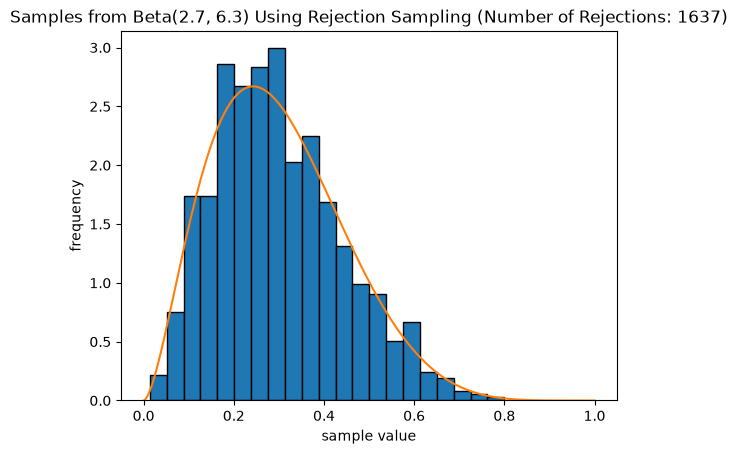

In [122]:
beta_samples, n_fails = gen_beta_simple(a=a, b=b, n_samples=1000)

# Plot the samples
plt.hist(
    beta_samples,
    bins='fd',
    density=True,
    edgecolor="black"
)

# plot the true density for comparison
plt.plot(
    x_grid,
    beta_pdf
)
plt.xlabel("sample value")
plt.ylabel("frequency")
plt.title(f"Samples from Beta(2.7, 6.3) Using Rejection Sampling (Number of Rejections: {n_fails})")
plt.show

The following is the code for the general algorithm that can take in a proposal density for $V$ instead of the uniform.

In [123]:
## True rejection sampling function:

# Helper fn: Getting M
def fetch_M(target, proposal, bounds=(0, 1)):
    # Unpacking
    target_pdf, target_args, target_kwargs = target
    proposal_pdf, proposal_args, proposal_kwargs = proposal

    # likelihood ratio to minimize
    def negative_lik_ratio(x):
        t_x = target_pdf(x, *target_args, **target_kwargs)
        p_x = proposal_pdf(x, *proposal_args, **proposal_kwargs)

        return -(t_x / p_x)
    
    result = minimize_scalar(negative_lik_ratio, bounds=bounds, method="bounded")

    return -result.fun

# One iteration of rejection sampling
def rs_iteration(target, proposal, sampler, bounds=(0, 1)):
    curr_fails = 0
    # unpacking
    target_pdf, target_args, target_kwargs = target
    proposal_pdf, proposal_args, proposal_kwargs = proposal
    prop_sampler, prop_sampler_args, prop_sampler_kwargs = sampler

    # Ensures we only generate one sample from proposal
    prop_sampler_kwargs["size"] = 1

    # Getting M
    M = fetch_M(target, proposal, bounds)

    # generate one sample
    y = np.inf
    while (y == np.inf):
        # Step 1
        U = uniform.rvs()
        V = prop_sampler(*prop_sampler_args, **prop_sampler_kwargs)
        f_prop_v = proposal_pdf(V, *proposal_args, **proposal_kwargs)
        f_target_v = target_pdf(V, *target_args, **target_kwargs)

        comparison_result = (1/M) * (f_target_v / f_prop_v)
        
        # Step 2
        if (U < comparison_result):
            y = V.item()
        else:
            curr_fails += 1
            continue

    return y, curr_fails


# Sampler
def rejection_sampling(target, proposal, sampler, n_samples=1, bounds=(0,1)):
    """
    target: tuple: (pdf function, pdf location args, pdf keyword args)
    proposal: tuple: (pdf function, pdf location args, pdf keyword args)
    sampler: tuple: (proposal density sampler function, sampler location args, sampler keyword args)
    bounds: bounds used for computing scalar M
    """
    n_fails = 0
    samples = np.zeros((n_samples,))


    for i in range(n_samples):
        sample, curr_iter_fails = rs_iteration(target, proposal, sampler, bounds)
        samples[i] = sample
        n_fails += curr_iter_fails

    return samples, n_fails


Testing our Rejection Sampler on simple case: sampling from a standard normal using a standard normal as a proposal density. We should get M=1.0, and zero rejections since our proposal is our target.

Computed M: 1.0
Number of rejections: 0


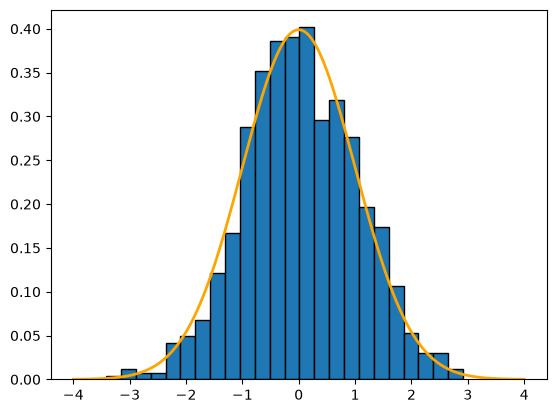

In [124]:
target = (norm.pdf, (), {})
# Passing kwargs to test code
proposal = (norm.pdf, (), {"loc": 0, "scale": 1})
sampler = (norm.rvs, (), {"loc": 0, "scale": 1})
bounds = (-3, 3)

# M should be 1.0
M = fetch_M(target, proposal, bounds)
print(f"Computed M: {M}")

std_norm_samples, n_fails = rejection_sampling(target, proposal, sampler, n_samples=1000, bounds=bounds)
print(f"Number of rejections: {n_fails}")

plt.hist(
    std_norm_samples,
    bins="fd",
    density=True,
    edgecolor="Black"
)

x_grid = np.linspace(-4,4,1000)
std_norm_pdf = norm.pdf(x_grid)
plt.plot(
    x_grid,
    std_norm_pdf,
    color="orange",
    lw=2
)
plt.show()

Now let us apply it to our Beta scenario above and see if we get similar results to our basic function. Our proposal will be a uniform(0,1).

Number of rejected samples: 1701


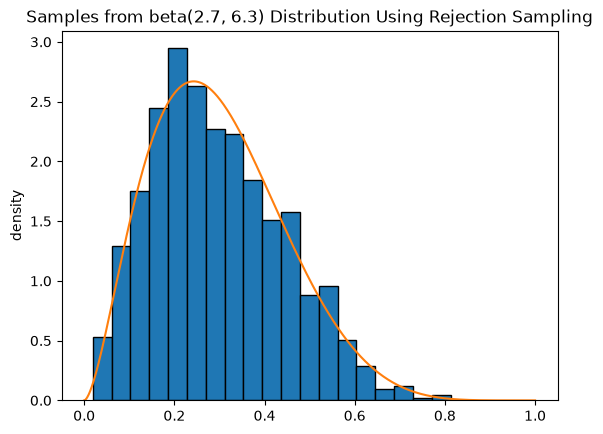

In [125]:
# pdf to compare
x_grid = np.linspace(0,1,1000)
beta_pdf = beta.pdf(x_grid, 2.7, 6.3)

# Recall leaving the args and/or kwargs empty means using the default args 
proposal = (uniform.pdf, (), {})
target = (beta.pdf, (2.7, 6.3), {})
sampler = (uniform.rvs, (), {})

beta_samples, n_fails = rejection_sampling(target, proposal, sampler, n_samples=1000, bounds=(0,1))
print(f"Number of rejected samples: {n_fails}")

plt.hist(
    beta_samples,
    bins='fd',
    density=True,
    ec="black"
)
plt.plot(
    x_grid,
    beta_pdf
)
plt.ylabel("density")
plt.title("Samples from beta(2.7, 6.3) Distribution Using Rejection Sampling")
plt.show()
